<a href="https://colab.research.google.com/github/profaHeloisaGuimaraes/ciencia-de-dados20252/blob/Unidade-II/U2A1_notebook_codigos_slides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compreensão Aprofundada dos Dados - Códigos Python

Este notebook contém todos os códigos Python apresentados nos slides da aula sobre **Compreensão Aprofundada dos Dados**.

**Tópicos abordados:**
- Estatísticas Descritivas
- Tipos de Dados
- Valores Nulos
- Outliers

**Bibliotecas utilizadas:** pandas, numpy, matplotlib, seaborn

## 1. Importação das Bibliotecas

In [1]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações para melhor visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração Inicial dos Dados

In [2]:
# Configurando a conexão com o Google Drive

from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/UNIFSA/Presencial/2025.2/Ciência de Dados/Aulas/'

Mounted at /content/drive


In [3]:
# Carregando o dataset de exemplo
df = pd.read_csv(path+'vendas_eletronicos.csv')

# Exibindo as primeiras linhas
print("Primeiras 5 linhas do dataset:")
print(df.head())

print("\n" + "="*50)
print("Informações gerais do dataset:")
print(df.info())

print("\n" + "="*50)
print("Dimensões do dataset:")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

Primeiras 5 linhas do dataset:
   ID        Produto     Categoria    Preço  Qtd_Vendida  Avaliação
0   1   Smartphone X     Celulares  3172.86          9.0        NaN
1   2   Tablet Basic       Tablets  1935.18        111.0        1.9
2   3    Mini Tablet       Tablets   468.89         42.0        3.8
3   4     TV LED 32"           TVs  3245.95          1.0        4.0
4   5  PC All-in-One  Computadores  4381.65         49.0        2.3

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           50 non-null     int64  
 1   Produto      50 non-null     object 
 2   Categoria    50 non-null     object 
 3   Preço        44 non-null     float64
 4   Qtd_Vendida  43 non-null     float64
 5   Avaliação    45 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 2.5+ KB
None

Dimensões do dataset:
L

## 3. Estatísticas Descritivas

### 3.1 Estatísticas Básicas

In [4]:
# Estatísticas descritivas básicas
print("Estatísticas descritivas para variáveis numéricas:")
print(df.describe())

print("\n" + "="*50)
print("Estatísticas descritivas para variáveis categóricas:")
print(df.describe(include=['object']))

Estatísticas descritivas para variáveis numéricas:
             ID        Preço  Qtd_Vendida  Avaliação
count  50.00000    44.000000    43.000000  45.000000
mean   25.50000  2585.079773    24.953488   2.666667
std    14.57738  2113.424840    27.195022   1.167748
min     1.00000    57.120000     1.000000   1.000000
25%    13.25000   962.277500     8.500000   1.700000
50%    25.50000  2085.960000    16.000000   2.700000
75%    37.75000  3301.682500    37.500000   3.800000
max    50.00000  8165.950000   142.000000   4.800000

Estatísticas descritivas para variáveis categóricas:
             Produto  Categoria
count             50         50
unique            21          5
top     Tablet Basic  Celulares
freq               6         12


### 3.2 Medidas de Tendência Central

In [26]:
# Calculando medidas de tendência central para a coluna 'Preco'
if 'Preço' in df.columns:
    preco = df['Preço'].dropna()

    print("Medidas de Tendência Central para Preço:")
    print(f"Média: R$ {preco.mean():.2f}")
    print(f"Mediana: R$ {preco.median():.2f}")
    print(f"Moda: R$ {preco.mode().iloc[0]:.2f}")

    # Média aparada (trimmed mean) - remove 10% dos valores extremos
    media_aparada = stats.trim_mean(preco, 0.1)
    print(f"Média Aparada (10%): R$ {media_aparada:.2f}")
else:
    print("Coluna 'Preco' não encontrada no dataset")

Medidas de Tendência Central para Preço:
Média: R$ 2585.08
Mediana: R$ 2085.96
Moda: R$ 57.12
Média Aparada (10%): R$ 2333.54


### 3.3 Medidas de Dispersão

In [27]:
# Calculando medidas de dispersão
if 'Preço' in df.columns:
    preco = df['Preço'].dropna()

    print("Medidas de Dispersão para Preço:")
    print(f"Variância: {preco.var():.2f}")
    print(f"Desvio Padrão: R$ {preco.std():.2f}")
    print(f"Amplitude: R$ {preco.max() - preco.min():.2f}")

    # Quartis e IQR
    Q1 = preco.quantile(0.25)
    Q2 = preco.quantile(0.50)  # Mediana
    Q3 = preco.quantile(0.75)
    IQR = Q3 - Q1

    print(f"\nQuartis:")
    print(f"Q1 (25%): R$ {Q1:.2f}")
    print(f"Q2 (50% - Mediana): R$ {Q2:.2f}")
    print(f"Q3 (75%): R$ {Q3:.2f}")
    print(f"IQR (Intervalo Interquartil): R$ {IQR:.2f}")

    # Coeficiente de variação
    cv = (preco.std() / preco.mean()) * 100
    print(f"\nCoeficiente de Variação: {cv:.2f}%")
else:
    print("Coluna 'Preco' não encontrada no dataset")

Medidas de Dispersão para Preço:
Variância: 4466564.56
Desvio Padrão: R$ 2113.42
Amplitude: R$ 8108.83

Quartis:
Q1 (25%): R$ 962.28
Q2 (50% - Mediana): R$ 2085.96
Q3 (75%): R$ 3301.68
IQR (Intervalo Interquartil): R$ 2339.40

Coeficiente de Variação: 81.75%


### 3.4 Distribuição dos Dados

In [28]:
# Análise da distribuição dos dados
if 'Preço' in df.columns:
    preco = df['Preço'].dropna()

    # Assimetria (skewness) e curtose (kurtosis)
    assimetria = preco.skew()
    curtose = preco.kurtosis()

    print("Análise da Distribuição:")
    print(f"Assimetria (Skewness): {assimetria:.3f}")
    if assimetria > 0:
        print("  → Distribuição assimétrica à direita (cauda longa à direita)")
    elif assimetria < 0:
        print("  → Distribuição assimétrica à esquerda (cauda longa à esquerda)")
    else:
        print("  → Distribuição simétrica")

    print(f"\nCurtose: {curtose:.3f}")
    if curtose > 0:
        print("  → Distribuição leptocúrtica (mais pontiaguda que a normal)")
    elif curtose < 0:
        print("  → Distribuição platicúrtica (mais achatada que a normal)")
    else:
        print("  → Distribuição mesocúrtica (similar à normal)")
else:
    print("Coluna 'Preco' não encontrada no dataset")

Análise da Distribuição:
Assimetria (Skewness): 0.994
  → Distribuição assimétrica à direita (cauda longa à direita)

Curtose: 0.401
  → Distribuição leptocúrtica (mais pontiaguda que a normal)


### 3.5 Visualização das Estatísticas

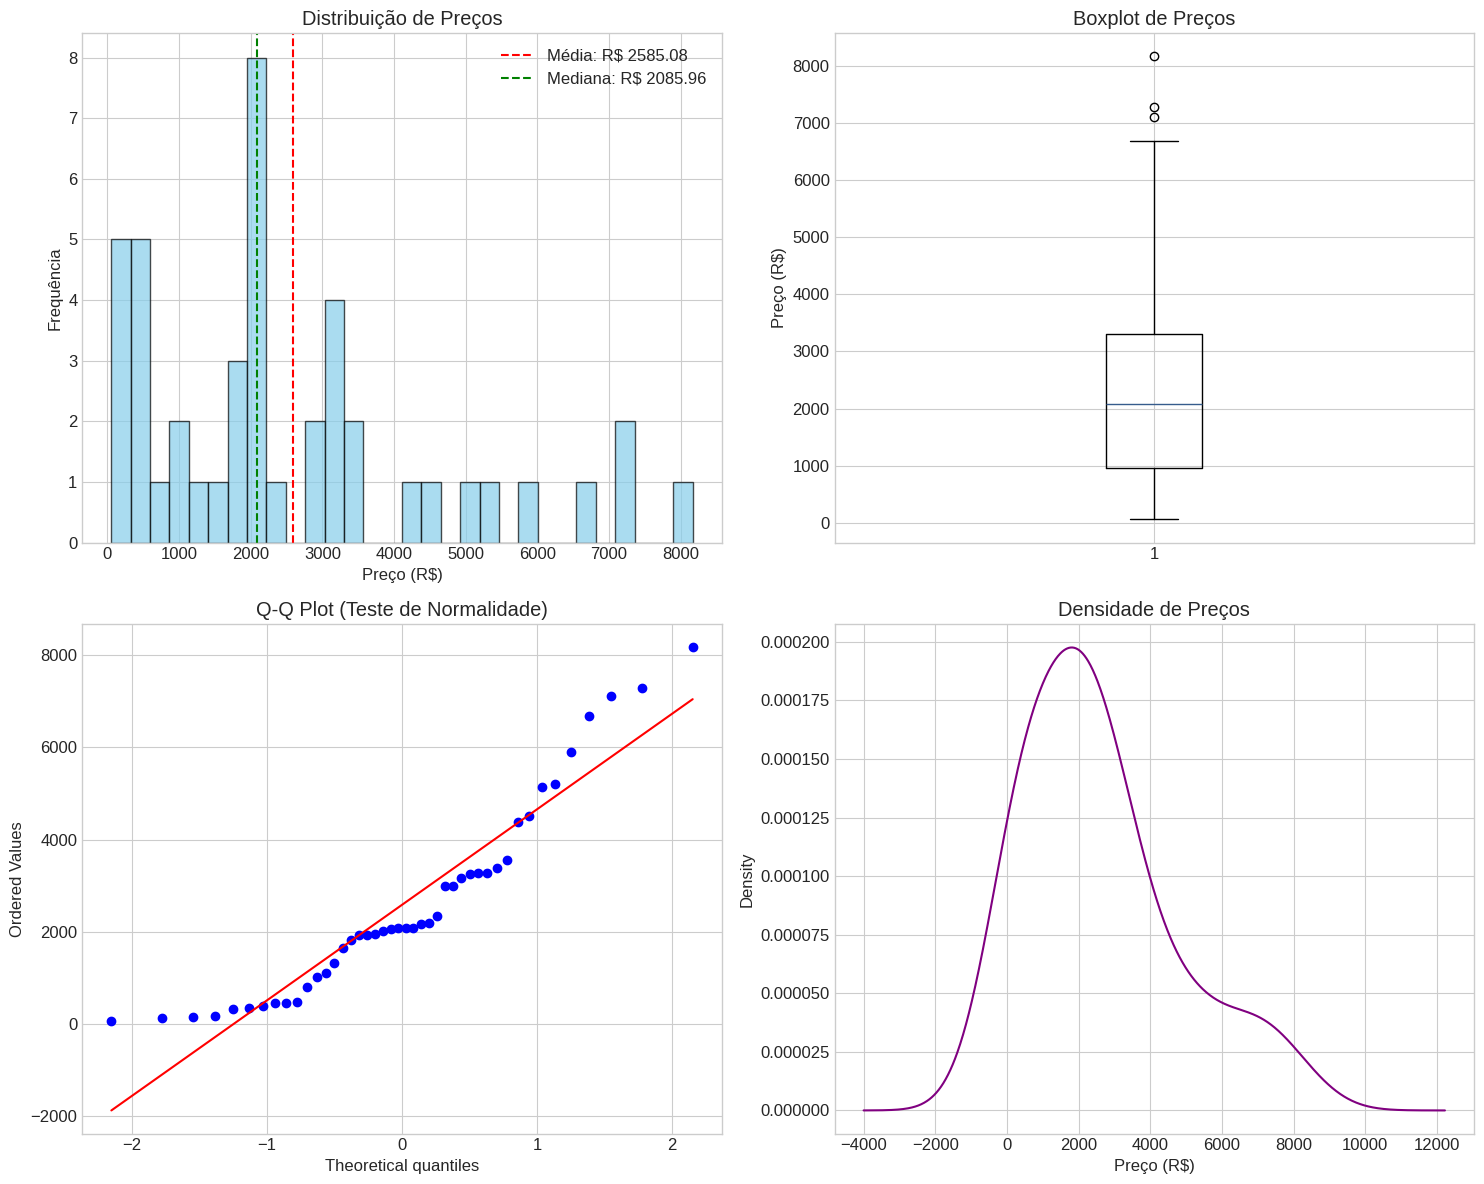

In [35]:
# Criando visualizações para as estatísticas descritivas
if 'Preço' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Histograma
    axes[0, 0].hist(df['Preço'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df['Preço'].mean(), color='red', linestyle='--', label=f'Média: R$ {df["Preço"].mean():.2f}')
    axes[0, 0].axvline(df['Preço'].median(), color='green', linestyle='--', label=f'Mediana: R$ {df["Preço"].median():.2f}')
    axes[0, 0].set_title('Distribuição de Preços')
    axes[0, 0].set_xlabel('Preço (R$)')
    axes[0, 0].set_ylabel('Frequência')
    axes[0, 0].legend()

    # Boxplot
    axes[0, 1].boxplot(df['Preço'].dropna())
    axes[0, 1].set_title('Boxplot de Preços')
    axes[0, 1].set_ylabel('Preço (R$)')

    # Q-Q Plot para verificar normalidade
    stats.probplot(df['Preço'].dropna(), dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot (Teste de Normalidade)')

    # Densidade
    df['Preço'].dropna().plot(kind='density', ax=axes[1, 1], color='purple')
    axes[1, 1].set_title('Densidade de Preços')
    axes[1, 1].set_xlabel('Preço (R$)')

    plt.tight_layout()
    plt.show()
else:
    print("Coluna 'Preco' não encontrada no dataset")

## 4. Tipos de Dados

### 4.1 Identificação dos Tipos de Dados

In [9]:
# Verificando os tipos de dados atuais
print("Tipos de dados atuais:")
print(df.dtypes)

print("\n" + "="*50)
print("Informações detalhadas sobre os tipos:")
for coluna in df.columns:
    tipo = df[coluna].dtype
    valores_unicos = df[coluna].nunique()
    valores_nulos = df[coluna].isnull().sum()

    print(f"{coluna}:")
    print(f"  Tipo: {tipo}")
    print(f"  Valores únicos: {valores_unicos}")
    print(f"  Valores nulos: {valores_nulos}")
    print()

Tipos de dados atuais:
ID               int64
Produto         object
Categoria       object
Preço          float64
Qtd_Vendida    float64
Avaliação      float64
dtype: object

Informações detalhadas sobre os tipos:
ID:
  Tipo: int64
  Valores únicos: 50
  Valores nulos: 0

Produto:
  Tipo: object
  Valores únicos: 21
  Valores nulos: 0

Categoria:
  Tipo: object
  Valores únicos: 5
  Valores nulos: 0

Preço:
  Tipo: float64
  Valores únicos: 44
  Valores nulos: 6

Qtd_Vendida:
  Tipo: float64
  Valores únicos: 27
  Valores nulos: 7

Avaliação:
  Tipo: float64
  Valores únicos: 26
  Valores nulos: 5



### 4.2 Conversão de Tipos de Dados

In [10]:
# Exemplo de conversões de tipos de dados
df_convertido = df.copy()

# Convertendo data para datetime (se existir coluna de data)
if 'Data_Venda' in df_convertido.columns:
    df_convertido['Data_Venda'] = pd.to_datetime(df_convertido['Data_Venda'], errors='coerce')
    print("Coluna 'Data_Venda' convertida para datetime")

# Convertendo variável booleana (se existir)
if 'Garantia_Estendida' in df_convertido.columns:
    # Mapeamento de strings para booleano
    mapeamento_bool = {'Sim': True, 'Não': False, 'Yes': True, 'No': False}
    df_convertido['Garantia_Estendida'] = df_convertido['Garantia_Estendida'].map(mapeamento_bool)
    print("Coluna 'Garantia_Estendida' convertida para booleano")

# Convertendo para categoria (economiza memória para variáveis categóricas)
if 'Categoria' in df_convertido.columns:
    df_convertido['Categoria'] = df_convertido['Categoria'].astype('category')
    print("Coluna 'Categoria' convertida para tipo categórico")

if 'Forma_Pagamento' in df_convertido.columns:
    df_convertido['Forma_Pagamento'] = df_convertido['Forma_Pagamento'].astype('category')
    print("Coluna 'Forma_Pagamento' convertida para tipo categórico")

print("\n" + "="*50)
print("Tipos de dados após conversão:")
print(df_convertido.dtypes)

Coluna 'Categoria' convertida para tipo categórico

Tipos de dados após conversão:
ID                int64
Produto          object
Categoria      category
Preço           float64
Qtd_Vendida     float64
Avaliação       float64
dtype: object


### 4.3 Análise de Dados Quantitativos

Variáveis Quantitativas encontradas:
- ID
- Preço
- Qtd_Vendida
- Avaliação

Análise das variáveis quantitativas:

Matriz de Correlação:
                   ID     Preço  Qtd_Vendida  Avaliação
ID           1.000000  0.174937    -0.136473  -0.295508
Preço        0.174937  1.000000    -0.133385  -0.160433
Qtd_Vendida -0.136473 -0.133385     1.000000  -0.235697
Avaliação   -0.295508 -0.160433    -0.235697   1.000000


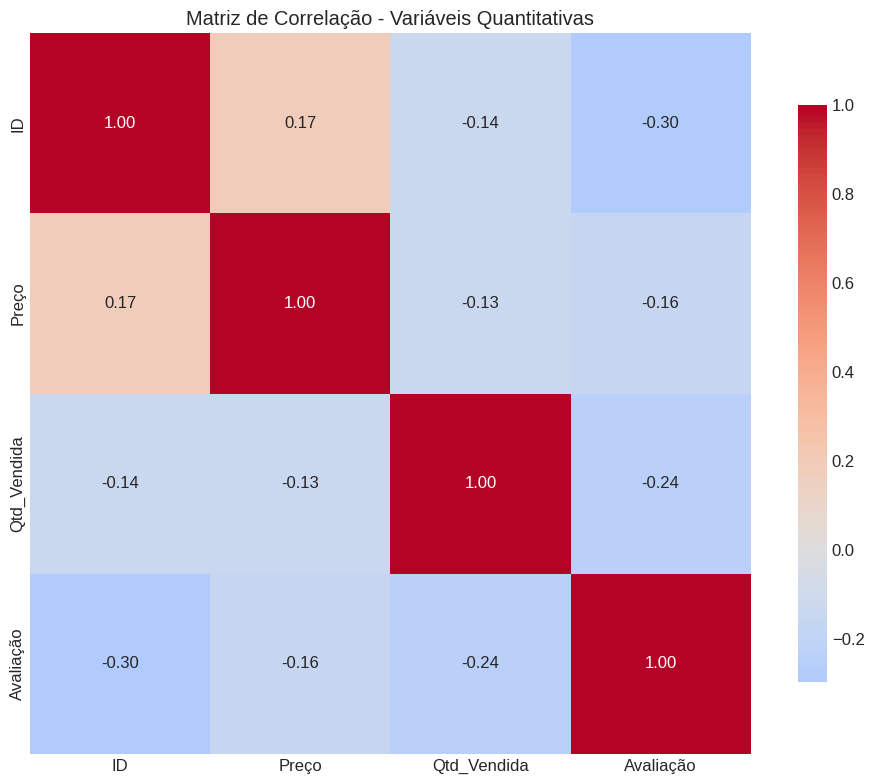

In [11]:
# Identificando e analisando variáveis quantitativas
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

print("Variáveis Quantitativas encontradas:")
for coluna in colunas_numericas:
    print(f"- {coluna}")

if colunas_numericas:
    print("\n" + "="*50)
    print("Análise das variáveis quantitativas:")

    # Correlação entre variáveis numéricas
    correlacao = df[colunas_numericas].corr()
    print("\nMatriz de Correlação:")
    print(correlacao)

    # Visualização da matriz de correlação
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlacao, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title('Matriz de Correlação - Variáveis Quantitativas')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma variável quantitativa encontrada")

### 4.4 Análise de Dados Qualitativos

Variáveis Qualitativas encontradas:
- Produto
- Categoria

Análise das variáveis qualitativas:

Produto:
                   Contagem  Percentual
Produto                                
Tablet Basic              6        12.0
Smartphone Ultra          5        10.0
Notebook Slim             4         8.0
TV LED 43"                4         8.0
Smartphone X              3         6.0
Notebook Básico           3         6.0
Capa Protetora            3         6.0
Mini Tablet               3         6.0
Smartphone Y Pro          3         6.0
Mouse Gamer               3         6.0
Tablet Pro                2         4.0
Fone Bluetooth            2         4.0
TV LED 32"                1         2.0
PC All-in-One             1         2.0
Smart TV 65" 4K           1         2.0
Celular Basic             1         2.0
Smart TV 50"              1         2.0
Carregador Rápido         1         2.0
TV OLED 55"               1         2.0
Tablet Premium            1         2.0
Teclado Mecânic

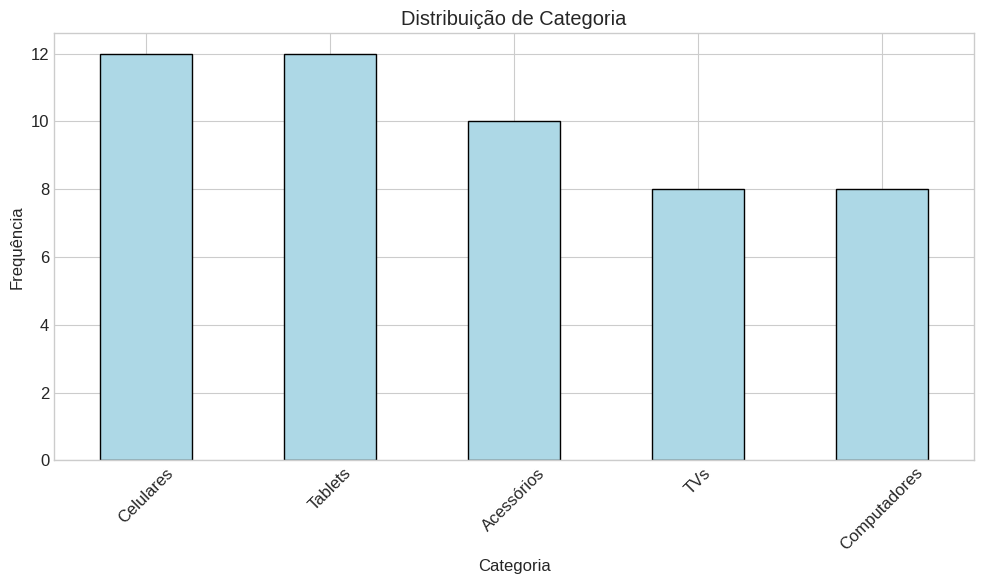

In [12]:
# Identificando e analisando variáveis qualitativas
colunas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variáveis Qualitativas encontradas:")
for coluna in colunas_categoricas:
    print(f"- {coluna}")

if colunas_categoricas:
    print("\n" + "="*50)
    print("Análise das variáveis qualitativas:")

    for coluna in colunas_categoricas:
        print(f"\n{coluna}:")
        contagem = df[coluna].value_counts()
        percentual = df[coluna].value_counts(normalize=True) * 100

        resultado = pd.DataFrame({
            'Contagem': contagem,
            'Percentual': percentual
        })
        print(resultado)

        # Visualização
        if len(contagem) <= 10:  # Só plotar se não tiver muitas categorias
            plt.figure(figsize=(10, 6))
            contagem.plot(kind='bar', color='lightblue', edgecolor='black')
            plt.title(f'Distribuição de {coluna}')
            plt.xlabel(coluna)
            plt.ylabel('Frequência')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
else:
    print("Nenhuma variável qualitativa encontrada")

## 5. Valores Nulos

### 5.1 Identificação de Valores Nulos

In [13]:
# Verificando valores nulos
print("Contagem de valores nulos por coluna:")
valores_nulos = df.isnull().sum()
percentual_nulos = (df.isnull().sum() / len(df)) * 100

resultado_nulos = pd.DataFrame({
    'Valores_Nulos': valores_nulos,
    'Percentual': percentual_nulos
})

# Ordenar por quantidade de valores nulos
resultado_nulos = resultado_nulos.sort_values('Valores_Nulos', ascending=False)
print(resultado_nulos)

# Total de valores nulos no dataset
total_nulos = df.isnull().sum().sum()
total_valores = df.size
percentual_total_nulos = (total_nulos / total_valores) * 100

print(f"\nTotal de valores nulos no dataset: {total_nulos}")
print(f"Percentual total de valores nulos: {percentual_total_nulos:.2f}%")

Contagem de valores nulos por coluna:
             Valores_Nulos  Percentual
Qtd_Vendida              7        14.0
Preço                    6        12.0
Avaliação                5        10.0
ID                       0         0.0
Produto                  0         0.0
Categoria                0         0.0

Total de valores nulos no dataset: 18
Percentual total de valores nulos: 6.00%


### 5.2 Visualização de Valores Nulos

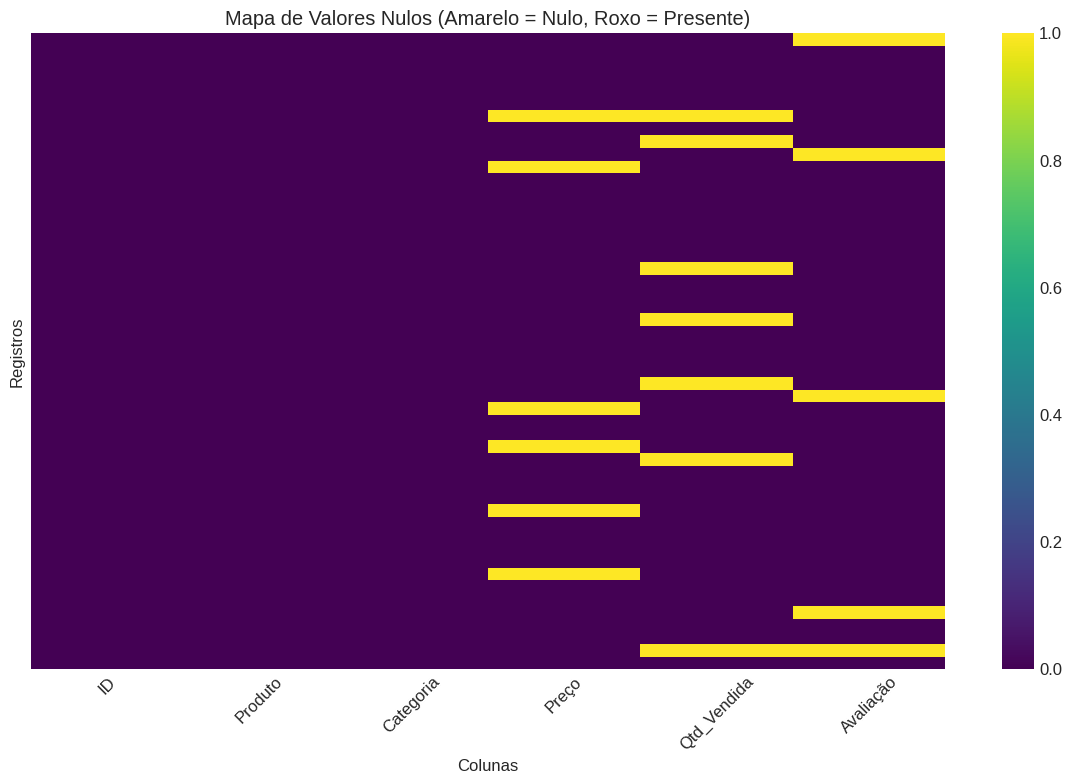

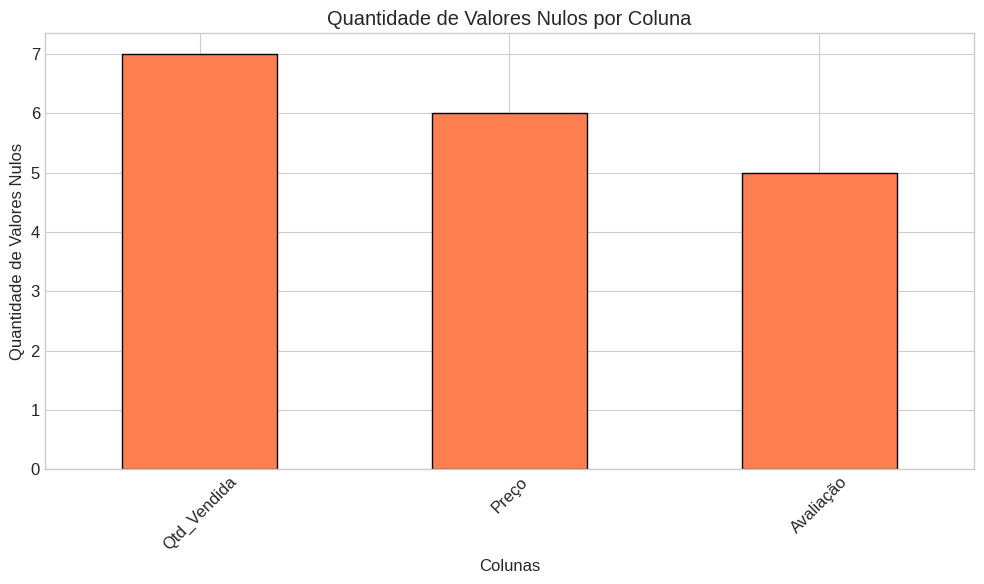

In [14]:
# Visualizando padrões de valores nulos
if df.isnull().sum().sum() > 0:
    # Mapa de calor dos valores nulos
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
    plt.title('Mapa de Valores Nulos (Amarelo = Nulo, Roxo = Presente)')
    plt.xlabel('Colunas')
    plt.ylabel('Registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Gráfico de barras para valores nulos por coluna
    colunas_com_nulos = resultado_nulos[resultado_nulos['Valores_Nulos'] > 0]
    if not colunas_com_nulos.empty:
        plt.figure(figsize=(10, 6))
        colunas_com_nulos['Valores_Nulos'].plot(kind='bar', color='coral', edgecolor='black')
        plt.title('Quantidade de Valores Nulos por Coluna')
        plt.xlabel('Colunas')
        plt.ylabel('Quantidade de Valores Nulos')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Não há valores nulos no dataset para visualizar.")

### 5.3 Tratamento de Valores Nulos

In [15]:
# Estratégias para tratamento de valores nulos
df_tratado = df.copy()

print("Aplicando estratégias de tratamento de valores nulos:")

# 1. Remoção de linhas com muitos valores nulos
# Remove linhas onde mais de 50% dos valores são nulos
limite_nulos = len(df.columns) * 0.5
df_tratado = df_tratado.dropna(thresh=len(df.columns) - limite_nulos)
print(f"Linhas removidas por excesso de valores nulos: {len(df) - len(df_tratado)}")

# 2. Imputação por mediana para variáveis numéricas
colunas_numericas = df_tratado.select_dtypes(include=[np.number]).columns
for coluna in colunas_numericas:
    if df_tratado[coluna].isnull().sum() > 0:
        mediana = df_tratado[coluna].median()
        df_tratado[coluna].fillna(mediana, inplace=True)
        print(f"Coluna '{coluna}': {df[coluna].isnull().sum()} valores nulos substituídos pela mediana ({mediana:.2f})")

# 3. Imputação por moda para variáveis categóricas
colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns
for coluna in colunas_categoricas:
    if df_tratado[coluna].isnull().sum() > 0:
        moda = df_tratado[coluna].mode().iloc[0] if not df_tratado[coluna].mode().empty else 'Não informado'
        df_tratado[coluna].fillna(moda, inplace=True)
        print(f"Coluna '{coluna}': {df[coluna].isnull().sum()} valores nulos substituídos pela moda ('{moda}')")

# Verificando se ainda existem valores nulos
print("\n" + "="*50)
print("Valores nulos após tratamento:")
print(df_tratado.isnull().sum())

if df_tratado.isnull().sum().sum() == 0:
    print("\n✅ Todos os valores nulos foram tratados com sucesso!")
else:
    print(f"\n⚠️  Ainda existem {df_tratado.isnull().sum().sum()} valores nulos no dataset.")

Aplicando estratégias de tratamento de valores nulos:
Linhas removidas por excesso de valores nulos: 0
Coluna 'Preço': 6 valores nulos substituídos pela mediana (2085.96)
Coluna 'Qtd_Vendida': 7 valores nulos substituídos pela mediana (16.00)
Coluna 'Avaliação': 5 valores nulos substituídos pela mediana (2.70)

Valores nulos após tratamento:
ID             0
Produto        0
Categoria      0
Preço          0
Qtd_Vendida    0
Avaliação      0
dtype: int64

✅ Todos os valores nulos foram tratados com sucesso!


### 5.4 Imputação Avançada

In [16]:
# Exemplo de imputação mais sofisticada usando sklearn
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder

# Preparando dados para imputação avançada (apenas se houver valores nulos)
if df.isnull().sum().sum() > 0:
    print("Demonstrando técnicas avançadas de imputação:")

    # Separando variáveis numéricas e categóricas
    df_num = df.select_dtypes(include=[np.number])
    df_cat = df.select_dtypes(include=['object'])

    # 1. Imputação KNN para variáveis numéricas
    if not df_num.empty and df_num.isnull().sum().sum() > 0:
        print("\n1. Imputação KNN para variáveis numéricas:")
        imputer_knn = KNNImputer(n_neighbors=5)
        df_num_knn = pd.DataFrame(
            imputer_knn.fit_transform(df_num),
            columns=df_num.columns,
            index=df_num.index
        )
        print("Imputação KNN aplicada com sucesso")

    # 2. Imputação por frequência para variáveis categóricas
    if not df_cat.empty and df_cat.isnull().sum().sum() > 0:
        print("\n2. Imputação por frequência para variáveis categóricas:")
        imputer_cat = SimpleImputer(strategy='most_frequent')
        df_cat_imputed = pd.DataFrame(
            imputer_cat.fit_transform(df_cat),
            columns=df_cat.columns,
            index=df_cat.index
        )
        print("Imputação por frequência aplicada com sucesso")

    print("\n✅ Técnicas avançadas de imputação demonstradas!")
else:
    print("Não há valores nulos para demonstrar técnicas avançadas de imputação.")

Demonstrando técnicas avançadas de imputação:

1. Imputação KNN para variáveis numéricas:
Imputação KNN aplicada com sucesso

✅ Técnicas avançadas de imputação demonstradas!


## 6. Outliers

### 6.1 Identificação de Outliers - Método Z-Score

In [17]:
# Função para detectar outliers usando Z-Score
def detectar_outliers_zscore(dados, limite=3):
    """
    Detecta outliers usando o método Z-Score

    Parâmetros:
    dados: Series - dados para análise
    limite: float - limite do Z-Score (padrão: 3)

    Retorna:
    dict: dicionário com informações sobre outliers
    """
    dados_limpos = dados.dropna()
    z_scores = np.abs(stats.zscore(dados_limpos))
    outliers_mask = z_scores > limite
    outliers = dados_limpos[outliers_mask]

    return {
        'outliers': outliers,
        'indices': outliers.index.tolist(),
        'z_scores': z_scores[outliers_mask],
        'quantidade': len(outliers),
        'percentual': (len(outliers) / len(dados_limpos)) * 100
    }

# Aplicando detecção de outliers para variáveis numéricas
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

print("DETECÇÃO DE OUTLIERS - MÉTODO Z-SCORE")
print("="*50)

resultados_zscore = {}
for coluna in colunas_numericas:
    resultado = detectar_outliers_zscore(df[coluna])
    resultados_zscore[coluna] = resultado

    print(f"\n{coluna}:")
    print(f"  Outliers encontrados: {resultado['quantidade']}")
    print(f"  Percentual: {resultado['percentual']:.2f}%")

    if resultado['quantidade'] > 0:
        print(f"  Valores outliers: {resultado['outliers'].tolist()[:5]}{'...' if len(resultado['outliers']) > 5 else ''}")
        print(f"  Z-Scores correspondentes: {resultado['z_scores'][:5].tolist()}{'...' if len(resultado['z_scores']) > 5 else ''}")

DETECÇÃO DE OUTLIERS - MÉTODO Z-SCORE

ID:
  Outliers encontrados: 0
  Percentual: 0.00%

Preço:
  Outliers encontrados: 0
  Percentual: 0.00%

Qtd_Vendida:
  Outliers encontrados: 2
  Percentual: 4.65%
  Valores outliers: [111.0, 142.0]
  Z-Scores correspondentes: [3.201499504172246, 4.354904595810518]

Avaliação:
  Outliers encontrados: 0
  Percentual: 0.00%


### 6.2 Identificação de Outliers - Método IQR

In [18]:
# Função para detectar outliers usando IQR
def detectar_outliers_iqr(dados):
    """
    Detecta outliers usando o método IQR (Intervalo Interquartil)

    Parâmetros:
    dados: Series - dados para análise

    Retorna:
    dict: dicionário com informações sobre outliers
    """
    dados_limpos = dados.dropna()
    Q1 = dados_limpos.quantile(0.25)
    Q3 = dados_limpos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers_mask = (dados_limpos < limite_inferior) | (dados_limpos > limite_superior)
    outliers = dados_limpos[outliers_mask]

    return {
        'outliers': outliers,
        'indices': outliers.index.tolist(),
        'quantidade': len(outliers),
        'percentual': (len(outliers) / len(dados_limpos)) * 100,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }

# Aplicando detecção de outliers IQR
print("\nDETECÇÃO DE OUTLIERS - MÉTODO IQR")
print("="*50)

resultados_iqr = {}
for coluna in colunas_numericas:
    resultado = detectar_outliers_iqr(df[coluna])
    resultados_iqr[coluna] = resultado

    print(f"\n{coluna}:")
    print(f"  Q1: {resultado['Q1']:.2f}")
    print(f"  Q3: {resultado['Q3']:.2f}")
    print(f"  IQR: {resultado['IQR']:.2f}")
    print(f"  Limite inferior: {resultado['limite_inferior']:.2f}")
    print(f"  Limite superior: {resultado['limite_superior']:.2f}")
    print(f"  Outliers encontrados: {resultado['quantidade']}")
    print(f"  Percentual: {resultado['percentual']:.2f}%")

    if resultado['quantidade'] > 0:
        print(f"  Valores outliers: {resultado['outliers'].tolist()[:5]}{'...' if len(resultado['outliers']) > 5 else ''}")


DETECÇÃO DE OUTLIERS - MÉTODO IQR

ID:
  Q1: 13.25
  Q3: 37.75
  IQR: 24.50
  Limite inferior: -23.50
  Limite superior: 74.50
  Outliers encontrados: 0
  Percentual: 0.00%

Preço:
  Q1: 962.28
  Q3: 3301.68
  IQR: 2339.40
  Limite inferior: -2546.83
  Limite superior: 6810.79
  Outliers encontrados: 3
  Percentual: 6.82%
  Valores outliers: [7103.79, 7286.76, 8165.95]

Qtd_Vendida:
  Q1: 8.50
  Q3: 37.50
  IQR: 29.00
  Limite inferior: -35.00
  Limite superior: 81.00
  Outliers encontrados: 2
  Percentual: 4.65%
  Valores outliers: [111.0, 142.0]

Avaliação:
  Q1: 1.70
  Q3: 3.80
  IQR: 2.10
  Limite inferior: -1.45
  Limite superior: 6.95
  Outliers encontrados: 0
  Percentual: 0.00%


### 6.3 Visualização de Outliers

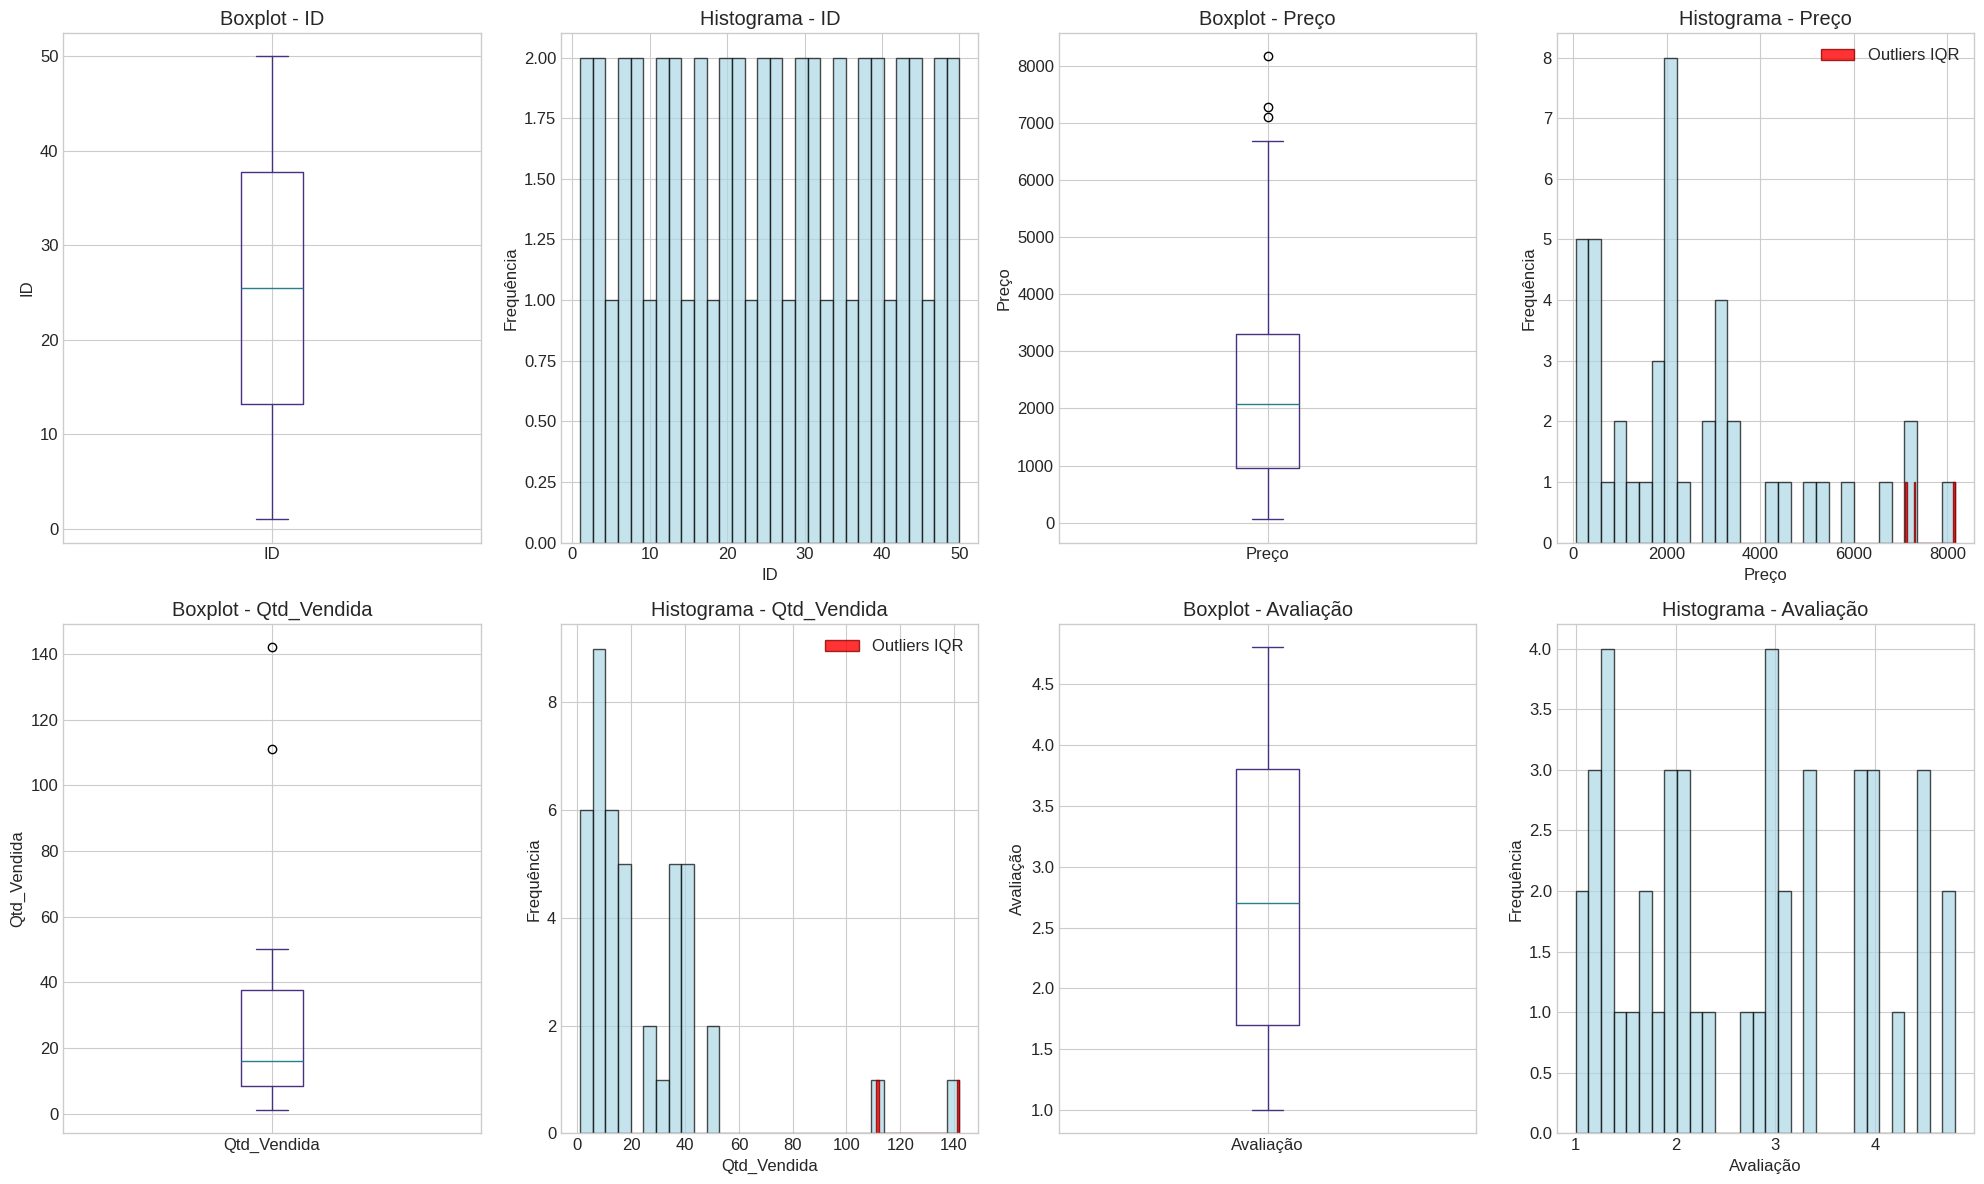

In [19]:
# Visualizando outliers para cada variável numérica
if colunas_numericas:
    n_cols = min(2, len(colunas_numericas))
    n_rows = (len(colunas_numericas) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(20, 6 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i, coluna in enumerate(colunas_numericas):
        row = i // n_cols
        col_box = (i % n_cols) * 2
        col_hist = col_box + 1

        # Boxplot
        if n_rows > 1:
            ax_box = axes[row, col_box]
            ax_hist = axes[row, col_hist]
        else:
            ax_box = axes[col_box]
            ax_hist = axes[col_hist]

        # Boxplot
        df[coluna].dropna().plot(kind='box', ax=ax_box)
        ax_box.set_title(f'Boxplot - {coluna}')
        ax_box.set_ylabel(coluna)

        # Histograma com outliers destacados
        dados_limpos = df[coluna].dropna()
        ax_hist.hist(dados_limpos, bins=30, alpha=0.7, color='lightblue', edgecolor='black')

        # Destacar outliers IQR
        if coluna in resultados_iqr:
            outliers_iqr = resultados_iqr[coluna]['outliers']
            if len(outliers_iqr) > 0:
                ax_hist.hist(outliers_iqr, bins=30, alpha=0.8, color='red', edgecolor='darkred', label='Outliers IQR')

        ax_hist.set_title(f'Histograma - {coluna}')
        ax_hist.set_xlabel(coluna)
        ax_hist.set_ylabel('Frequência')
        ax_hist.legend()

    # Remover subplots vazios
    for i in range(len(colunas_numericas), n_rows * n_cols):
        row = i // n_cols
        col_box = (i % n_cols) * 2
        col_hist = col_box + 1

        if n_rows > 1:
            fig.delaxes(axes[row, col_box])
            fig.delaxes(axes[row, col_hist])
        else:
            if col_box < len(axes):
                fig.delaxes(axes[col_box])
            if col_hist < len(axes):
                fig.delaxes(axes[col_hist])

    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma variável numérica encontrada para visualização de outliers.")

### 6.4 Comparação dos Métodos de Detecção

COMPARAÇÃO DOS MÉTODOS DE DETECÇÃO DE OUTLIERS
        Coluna  Z-Score  IQR  Diferença
0           ID        0    0          0
1        Preço        0    3          3
2  Qtd_Vendida        2    2          0
3    Avaliação        0    0          0


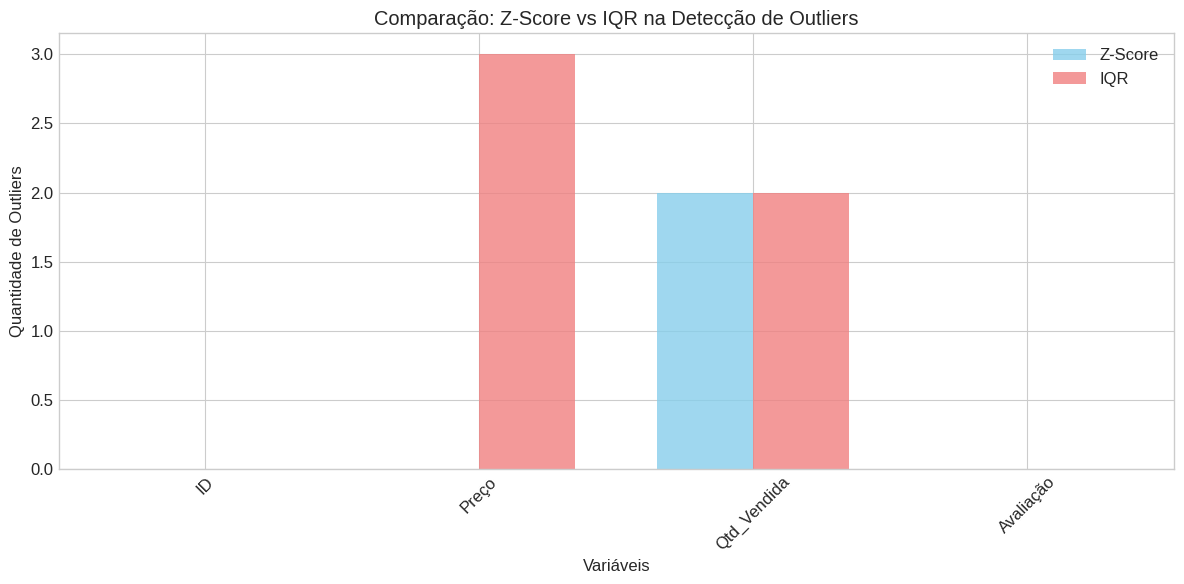

In [20]:
# Comparando os métodos Z-Score e IQR
print("COMPARAÇÃO DOS MÉTODOS DE DETECÇÃO DE OUTLIERS")
print("="*60)

comparacao = []
for coluna in colunas_numericas:
    zscore_count = resultados_zscore[coluna]['quantidade']
    iqr_count = resultados_iqr[coluna]['quantidade']

    comparacao.append({
        'Coluna': coluna,
        'Z-Score': zscore_count,
        'IQR': iqr_count,
        'Diferença': abs(zscore_count - iqr_count)
    })

df_comparacao = pd.DataFrame(comparacao)
print(df_comparacao)

# Visualização da comparação
if not df_comparacao.empty:
    plt.figure(figsize=(12, 6))
    x = np.arange(len(df_comparacao))
    width = 0.35

    plt.bar(x - width/2, df_comparacao['Z-Score'], width, label='Z-Score', alpha=0.8, color='skyblue')
    plt.bar(x + width/2, df_comparacao['IQR'], width, label='IQR', alpha=0.8, color='lightcoral')

    plt.xlabel('Variáveis')
    plt.ylabel('Quantidade de Outliers')
    plt.title('Comparação: Z-Score vs IQR na Detecção de Outliers')
    plt.xticks(x, df_comparacao['Coluna'], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 6.5 Tratamento de Outliers

ESTRATÉGIAS DE TRATAMENTO DE OUTLIERS
Demonstrando tratamento de outliers para a coluna: ID
Dados originais: 50 valores

1. REMOÇÃO DE OUTLIERS (método IQR):
  Outliers removidos: 0
  Dados restantes: 50
  Média original: 25.50
  Média após remoção: 25.50

2. TRUNCAMENTO (CAPPING):
  Valores truncados: 0
  Limite inferior aplicado: -23.50
  Limite superior aplicado: 74.50
  Média original: 25.50
  Média após truncamento: 25.50

3. TRANSFORMAÇÃO LOGARÍTMICA:
  Outliers antes da transformação: 0
  Outliers após transformação log: 2
  Assimetria original: 0.000
  Assimetria após log: -1.419

4. VISUALIZAÇÃO COMPARATIVA:


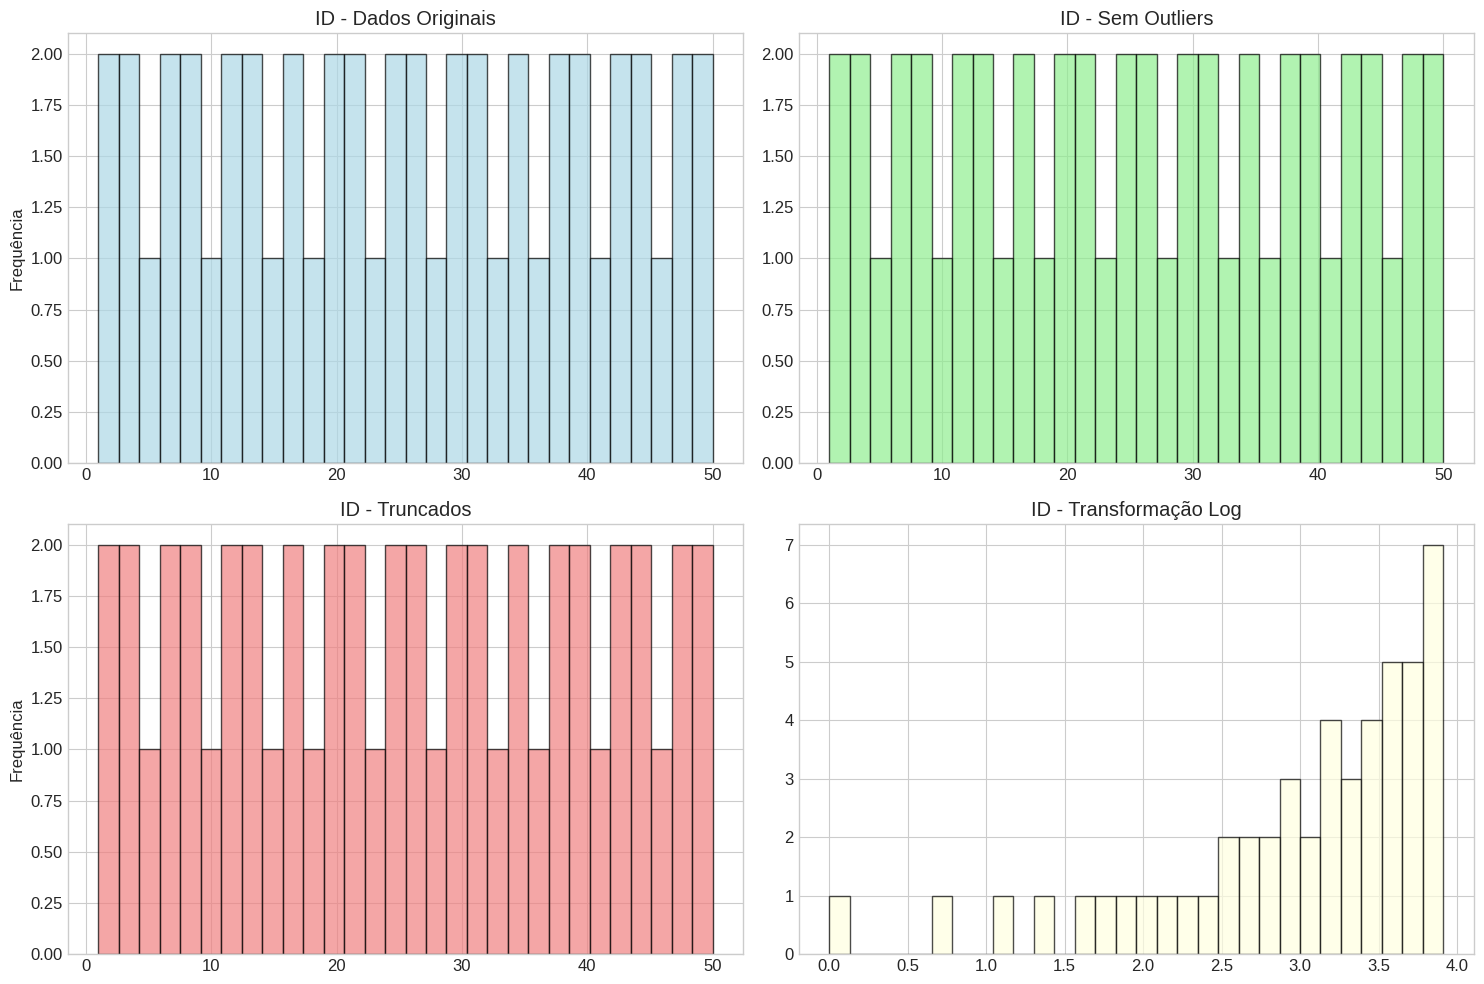

In [21]:
# Estratégias para tratamento de outliers
print("ESTRATÉGIAS DE TRATAMENTO DE OUTLIERS")
print("="*50)

# Escolhendo uma coluna para demonstrar o tratamento (primeira coluna numérica)
if colunas_numericas:
    coluna_exemplo = colunas_numericas[0]
    dados_originais = df[coluna_exemplo].dropna()

    print(f"Demonstrando tratamento de outliers para a coluna: {coluna_exemplo}")
    print(f"Dados originais: {len(dados_originais)} valores")

    # 1. REMOÇÃO DE OUTLIERS
    print("\n1. REMOÇÃO DE OUTLIERS (método IQR):")
    resultado_iqr_exemplo = resultados_iqr[coluna_exemplo]

    # Dados sem outliers
    mask_sem_outliers = ~dados_originais.index.isin(resultado_iqr_exemplo['indices'])
    dados_sem_outliers = dados_originais[mask_sem_outliers]

    print(f"  Outliers removidos: {len(dados_originais) - len(dados_sem_outliers)}")
    print(f"  Dados restantes: {len(dados_sem_outliers)}")
    print(f"  Média original: {dados_originais.mean():.2f}")
    print(f"  Média após remoção: {dados_sem_outliers.mean():.2f}")

    # 2. TRUNCAMENTO (CAPPING)
    print("\n2. TRUNCAMENTO (CAPPING):")
    dados_truncados = dados_originais.copy()

    limite_inf = resultado_iqr_exemplo['limite_inferior']
    limite_sup = resultado_iqr_exemplo['limite_superior']

    # Aplicar truncamento
    dados_truncados = np.where(
        dados_truncados > limite_sup, limite_sup,
        np.where(dados_truncados < limite_inf, limite_inf, dados_truncados)
    )

    outliers_truncados = np.sum((dados_originais > limite_sup) | (dados_originais < limite_inf))
    print(f"  Valores truncados: {outliers_truncados}")
    print(f"  Limite inferior aplicado: {limite_inf:.2f}")
    print(f"  Limite superior aplicado: {limite_sup:.2f}")
    print(f"  Média original: {dados_originais.mean():.2f}")
    print(f"  Média após truncamento: {np.mean(dados_truncados):.2f}")

    # 3. TRANSFORMAÇÃO LOGARÍTMICA
    print("\n3. TRANSFORMAÇÃO LOGARÍTMICA:")
    # Aplicar apenas se todos os valores forem positivos
    if dados_originais.min() > 0:
        dados_log = np.log(dados_originais)
        outliers_log = detectar_outliers_iqr(pd.Series(dados_log))

        print(f"  Outliers antes da transformação: {resultado_iqr_exemplo['quantidade']}")
        print(f"  Outliers após transformação log: {outliers_log['quantidade']}")
        print(f"  Assimetria original: {dados_originais.skew():.3f}")
        print(f"  Assimetria após log: {pd.Series(dados_log).skew():.3f}")
    else:
        print("  Transformação logarítmica não aplicável (valores negativos ou zero presentes)")

    # VISUALIZAÇÃO COMPARATIVA
    print("\n4. VISUALIZAÇÃO COMPARATIVA:")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Dados originais
    axes[0, 0].hist(dados_originais, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    axes[0, 0].set_title(f'{coluna_exemplo} - Dados Originais')
    axes[0, 0].set_ylabel('Frequência')

    # Dados sem outliers
    axes[0, 1].hist(dados_sem_outliers, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title(f'{coluna_exemplo} - Sem Outliers')

    # Dados truncados
    axes[1, 0].hist(dados_truncados, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].set_title(f'{coluna_exemplo} - Truncados')
    axes[1, 0].set_ylabel('Frequência')

    # Transformação logarítmica (se aplicável)
    if dados_originais.min() > 0:
        axes[1, 1].hist(dados_log, bins=30, alpha=0.7, color='lightyellow', edgecolor='black')
        axes[1, 1].set_title(f'{coluna_exemplo} - Transformação Log')
    else:
        axes[1, 1].text(0.5, 0.5, 'Transformação Log\nnão aplicável',
                        ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
        axes[1, 1].set_title(f'{coluna_exemplo} - Transformação Log')

    plt.tight_layout()
    plt.show()

else:
    print("Nenhuma variável numérica encontrada para demonstrar tratamento de outliers.")

### 6.6 Código Completo para Tratamento de Outliers

In [22]:
# Função completa para tratamento de outliers
def tratar_outliers(df, metodo='iqr', estrategia='truncamento', colunas=None):
    """
    Função completa para tratamento de outliers

    Parâmetros:
    df: DataFrame - dados para tratamento
    metodo: str - método de detecção ('iqr' ou 'zscore')
    estrategia: str - estratégia de tratamento ('remocao', 'truncamento', 'log')
    colunas: list - colunas específicas para tratar (None = todas numéricas)

    Retorna:
    DataFrame: dados tratados
    dict: relatório do tratamento
    """
    df_tratado = df.copy()
    relatorio = {}

    # Definir colunas a serem tratadas
    if colunas is None:
        colunas = df_tratado.select_dtypes(include=[np.number]).columns.tolist()

    for coluna in colunas:
        if coluna not in df_tratado.columns:
            continue

        dados_originais = df_tratado[coluna].dropna()

        # Detectar outliers
        if metodo == 'iqr':
            resultado_outliers = detectar_outliers_iqr(dados_originais)
        else:  # zscore
            resultado_outliers = detectar_outliers_zscore(dados_originais)

        outliers_count = resultado_outliers['quantidade']

        if outliers_count == 0:
            relatorio[coluna] = {'outliers_originais': 0, 'acao': 'nenhuma'}
            continue

        # Aplicar estratégia de tratamento
        if estrategia == 'remocao':
            # Remover linhas com outliers
            indices_outliers = resultado_outliers['indices']
            df_tratado = df_tratado.drop(indices_outliers)
            acao = f"Removidas {len(indices_outliers)} linhas"

        elif estrategia == 'truncamento':
            # Truncar valores extremos
            if metodo == 'iqr':
                limite_inf = resultado_outliers['limite_inferior']
                limite_sup = resultado_outliers['limite_superior']
            else:  # zscore
                limite_inf = dados_originais.mean() - 3 * dados_originais.std()
                limite_sup = dados_originais.mean() + 3 * dados_originais.std()

            df_tratado[coluna] = np.where(
                df_tratado[coluna] > limite_sup, limite_sup,
                np.where(df_tratado[coluna] < limite_inf, limite_inf, df_tratado[coluna])
            )
            acao = f"Truncamento aplicado (limites: {limite_inf:.2f} - {limite_sup:.2f})"

        elif estrategia == 'log' and dados_originais.min() > 0:
            # Transformação logarítmica
            df_tratado[coluna] = np.log(df_tratado[coluna])
            acao = "Transformação logarítmica aplicada"

        else:
            acao = "Estratégia não aplicável"

        relatorio[coluna] = {
            'outliers_originais': outliers_count,
            'acao': acao,
            'metodo': metodo,
            'estrategia': estrategia
        }

    return df_tratado, relatorio

# Exemplo de uso da função
print("EXEMPLO DE USO DA FUNÇÃO COMPLETA:")
print("="*50)

# Aplicar truncamento usando IQR
df_exemplo_tratado, relatorio_exemplo = tratar_outliers(
    df,
    metodo='iqr',
    estrategia='truncamento'
)

print("Relatório do tratamento:")
for coluna, info in relatorio_exemplo.items():
    print(f"\n{coluna}:")
    print(f"  Outliers originais: {info['outliers_originais']}")
    print(f"  Ação realizada: {info['acao']}")

print(f"\nDimensões originais: {df.shape}")
print(f"Dimensões após tratamento: {df_exemplo_tratado.shape}")

EXEMPLO DE USO DA FUNÇÃO COMPLETA:
Relatório do tratamento:

ID:
  Outliers originais: 0
  Ação realizada: nenhuma

Preço:
  Outliers originais: 3
  Ação realizada: Truncamento aplicado (limites: -2546.83 - 6810.79)

Qtd_Vendida:
  Outliers originais: 2
  Ação realizada: Truncamento aplicado (limites: -35.00 - 81.00)

Avaliação:
  Outliers originais: 0
  Ação realizada: nenhuma

Dimensões originais: (50, 6)
Dimensões após tratamento: (50, 6)


## 7. Análise Completa - Exemplo Prático

In [23]:
# Exemplo de análise completa aplicando todos os conceitos
print("ANÁLISE COMPLETA - EXEMPLO PRÁTICO")
print("="*50)

# 1. Carregamento e exploração inicial
print("1. EXPLORAÇÃO INICIAL:")
print(f"   Dataset shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
print(f"   Tipos de dados: {df.dtypes.value_counts().to_dict()}")

# 2. Análise de valores nulos
print("\n2. ANÁLISE DE VALORES NULOS:")
total_nulos = df.isnull().sum().sum()
print(f"   Total de valores nulos: {total_nulos}")
if total_nulos > 0:
    colunas_com_nulos = df.isnull().sum()[df.isnull().sum() > 0]
    print(f"   Colunas com valores nulos: {colunas_com_nulos.to_dict()}")

# 3. Análise de outliers
print("\n3. ANÁLISE DE OUTLIERS:")
total_outliers_iqr = sum([resultados_iqr[col]['quantidade'] for col in colunas_numericas])
total_outliers_zscore = sum([resultados_zscore[col]['quantidade'] for col in colunas_numericas])
print(f"   Total de outliers (IQR): {total_outliers_iqr}")
print(f"   Total de outliers (Z-Score): {total_outliers_zscore}")

# 4. Estatísticas descritivas principais
print("\n4. ESTATÍSTICAS DESCRITIVAS PRINCIPAIS:")
for coluna in colunas_numericas:
    dados = df[coluna].dropna()
    print(f"   {coluna}:")
    print(f"     Média: {dados.mean():.2f}")
    print(f"     Mediana: {dados.median():.2f}")
    print(f"     Desvio Padrão: {dados.std():.2f}")
    print(f"     Assimetria: {dados.skew():.3f}")

# 5. Recomendações finais
print("\n5. RECOMENDAÇÕES:")
recomendacoes = []

if total_nulos > 0:
    recomendacoes.append("Tratar valores nulos antes da análise")

if total_outliers_iqr > 0:
    recomendacoes.append("Investigar e tratar outliers identificados")

for coluna in colunas_numericas:
    assimetria = df[coluna].dropna().skew()
    if abs(assimetria) > 1:
        recomendacoes.append(f"Considerar transformação para {coluna} (assimetria alta: {assimetria:.2f})")

if recomendacoes:
    for i, rec in enumerate(recomendacoes, 1):
        print(f"   {i}. {rec}")
else:
    print("   Os dados estão em boas condições para análise!")

print("\n" + "="*50)
print("ANÁLISE COMPLETA FINALIZADA!")
print("="*50)

ANÁLISE COMPLETA - EXEMPLO PRÁTICO
1. EXPLORAÇÃO INICIAL:
   Dataset shape: (50, 6)
   Colunas: ['ID', 'Produto', 'Categoria', 'Preço', 'Qtd_Vendida', 'Avaliação']
   Tipos de dados: {dtype('float64'): 3, dtype('O'): 2, dtype('int64'): 1}

2. ANÁLISE DE VALORES NULOS:
   Total de valores nulos: 18
   Colunas com valores nulos: {'Preço': 6, 'Qtd_Vendida': 7, 'Avaliação': 5}

3. ANÁLISE DE OUTLIERS:
   Total de outliers (IQR): 5
   Total de outliers (Z-Score): 2

4. ESTATÍSTICAS DESCRITIVAS PRINCIPAIS:
   ID:
     Média: 25.50
     Mediana: 25.50
     Desvio Padrão: 14.58
     Assimetria: 0.000
   Preço:
     Média: 2585.08
     Mediana: 2085.96
     Desvio Padrão: 2113.42
     Assimetria: 0.994
   Qtd_Vendida:
     Média: 24.95
     Mediana: 16.00
     Desvio Padrão: 27.20
     Assimetria: 2.704
   Avaliação:
     Média: 2.67
     Mediana: 2.70
     Desvio Padrão: 1.17
     Assimetria: 0.259

5. RECOMENDAÇÕES:
   1. Tratar valores nulos antes da análise
   2. Investigar e tratar outlier

## 8. Resumo dos Códigos e Funções Úteis

In [24]:
# RESUMO DOS CÓDIGOS MAIS ÚTEIS PARA ANÁLISE DE DADOS

print("CÓDIGOS ESSENCIAIS PARA ANÁLISE DE DADOS")
print("="*50)

print("""
1. EXPLORAÇÃO INICIAL:
   df.head()                    # Primeiras linhas
   df.info()                    # Informações gerais
   df.describe()                # Estatísticas descritivas
   df.shape                     # Dimensões
   df.dtypes                    # Tipos de dados

2. VALORES NULOS:
   df.isnull().sum()            # Contagem de nulos
   df.dropna()                  # Remover nulos
   df.fillna(valor)             # Preencher nulos
   df.fillna(df.mean())         # Preencher com média
   df.fillna(df.mode().iloc[0]) # Preencher com moda

3. OUTLIERS (IQR):
   Q1 = df['col'].quantile(0.25)
   Q3 = df['col'].quantile(0.75)
   IQR = Q3 - Q1
   limite_inf = Q1 - 1.5 * IQR
   limite_sup = Q3 + 1.5 * IQR
   outliers = df[(df['col'] < limite_inf) | (df['col'] > limite_sup)]

4. OUTLIERS (Z-SCORE):
   from scipy import stats
   z_scores = np.abs(stats.zscore(df['col']))
   outliers = df[z_scores > 3]

5. VISUALIZAÇÕES:
   df['col'].hist()             # Histograma
   df.boxplot()                 # Boxplot
   sns.heatmap(df.corr())       # Matriz de correlação
   sns.scatterplot(x, y)        # Gráfico de dispersão

6. TRANSFORMAÇÕES:
   np.log(df['col'])            # Transformação logarítmica
   np.sqrt(df['col'])           # Transformação raiz quadrada
   df['col'].astype('category') # Converter para categórico
   pd.to_datetime(df['col'])    # Converter para datetime
""")

print("\nEste notebook contém todos os códigos apresentados nos slides!")
print("Use-o como referência para suas análises de dados.")

CÓDIGOS ESSENCIAIS PARA ANÁLISE DE DADOS

1. EXPLORAÇÃO INICIAL:
   df.head()                    # Primeiras linhas
   df.info()                    # Informações gerais
   df.describe()                # Estatísticas descritivas
   df.shape                     # Dimensões
   df.dtypes                    # Tipos de dados

2. VALORES NULOS:
   df.isnull().sum()            # Contagem de nulos
   df.dropna()                  # Remover nulos
   df.fillna(valor)             # Preencher nulos
   df.fillna(df.mean())         # Preencher com média
   df.fillna(df.mode().iloc[0]) # Preencher com moda

3. OUTLIERS (IQR):
   Q1 = df['col'].quantile(0.25)
   Q3 = df['col'].quantile(0.75)
   IQR = Q3 - Q1
   limite_inf = Q1 - 1.5 * IQR
   limite_sup = Q3 + 1.5 * IQR
   outliers = df[(df['col'] < limite_inf) | (df['col'] > limite_sup)]

4. OUTLIERS (Z-SCORE):
   from scipy import stats
   z_scores = np.abs(stats.zscore(df['col']))
   outliers = df[z_scores > 3]

5. VISUALIZAÇÕES:
   df['col'].hist()  